In [1]:
# Cell 1 - Imports
import numpy as np
import matplotlib.pyplot as plt
import mlx.core as mx
from numpy.fft import fftfreq
import xsmurf_wrapper as xsm
from xsmurf_wrapper.wavelet import gkapa_numpy, gkapap_numpy

%matplotlib inline

InSAR velocity: (3029, 4855), dtype=float32, range [-0.215, 0.156]


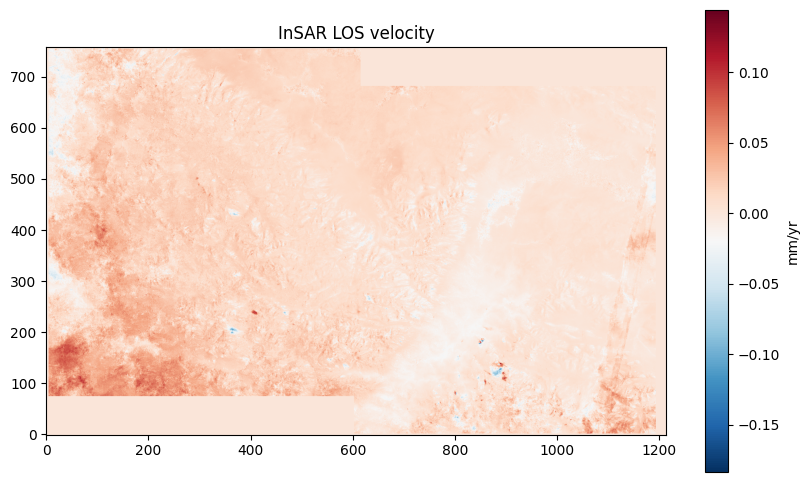

In [2]:
# Cell 2 - Load InSAR velocity data
import h5py

h5_path = '/Volumes/AbeMBeats/new_data_asif/velocity.h5'
with h5py.File(h5_path, 'r') as f:
    image = f['velocity'][:].astype(np.float32)

image = np.nan_to_num(image, nan=0.0).astype(np.float32)
ly, lx = image.shape

print(f'InSAR velocity: {image.shape}, dtype={image.dtype}, range [{image.min():.3f}, {image.max():.3f}]')
plt.figure(figsize=(10, 6))
plt.imshow(image[::4, ::4], origin='lower', cmap='RdBu_r', rasterized=True)
plt.colorbar(label='mm/yr')
plt.title('InSAR LOS velocity')
plt.show()

In [3]:
# Cell 3 - CWT functions: MLX GPU, float32, xsmurf-matched frequency convention
#
# Key conventions (matching xsmurf im_mult_analog):
#   - Normalized frequency: kx = fftfreq(N) * scale  (NO 2*pi)
#   - Plain Fourier multiplication (no conjugate)
#   - float32 throughout (matches MPS GPU + xsmurf typedef float real)
#
# Wavelet filters match wavelet.py WAVELET_EXPRS:
#   dx:   (0, x*exp(-x*x-y*y))       -> imaginary part = kx * gauss
#   dy:   (0, y*exp(-x*x-y*y))       -> imaginary part = ky * gauss
#   dxx:  (-x*x*exp(-x*x-y*y), 0)    -> real part = -kx*kx * gauss
#   dxy:  (-y*x*exp(-x*x-y*y), 0)    -> real part = -ky*kx * gauss
#   dyy:  (-y*y*exp(-x*x-y*y), 0)    -> real part = -ky*ky * gauss
#   dxxx: (0, -x*x*x*exp(-x*x-y*y))  -> imaginary part = -kx^3 * gauss
#   dxxy: (0, -x*x*y*exp(-x*x-y*y))  -> imaginary part = -kx^2*ky * gauss
#   dxyy: (0, -x*y*y*exp(-x*x-y*y))  -> imaginary part = -kx*ky^2 * gauss
#   dyyy: (0, -y*y*y*exp(-x*x-y*y))  -> imaginary part = -ky^3 * gauss

def compute_scales(n_oct, n_vox, a_min=1.0):
    """Compute xsmurf-convention wavelet scales."""
    norm = 6.0 / 0.86
    scales = []
    for o in range(n_oct):
        for v in range(n_vox):
            scales.append(a_min * (2.0 ** (o + v / n_vox)) * norm)
    return scales


def _build_wavelet_filters_f32(kx, ky, scale):
    """Build all 9 wavelet derivative filters at given scale.
    
    kx, ky: MLX float32 frequency grids (from fftfreq, NO 2*pi)
    scale: wavelet scale
    
    Returns dict of 9 complex64 MLX arrays (filter in Fourier domain).
    Each filter = complex(real_part, imag_part) matching WAVELET_EXPRS.
    """
    # Scaled frequency (matching xsmurf: x = i*scale/lx)
    sx = kx * scale
    sy = ky * scale
    gauss = mx.exp(-(sx * sx + sy * sy))
    zero = mx.zeros_like(gauss)
    
    def to_complex(r, i):
        """Build complex64 from real and imaginary float32 parts."""
        return mx.stack([r, i], axis=-1).view(mx.complex64).squeeze(-1)
    
    return {
        # 1st order (imaginary)
        'dx':   to_complex(zero,               sx * gauss),
        'dy':   to_complex(zero,               sy * gauss),
        # 2nd order (real)
        'dxx':  to_complex(-sx * sx * gauss,   zero),
        'dxy':  to_complex(-sy * sx * gauss,   zero),
        'dyy':  to_complex(-sy * sy * gauss,   zero),
        # 3rd order (imaginary, negative)
        'dxxx': to_complex(zero, -sx * sx * sx * gauss),
        'dxxy': to_complex(zero, -sx * sx * sy * gauss),
        'dxyy': to_complex(zero, -sx * sy * sy * gauss),
        'dyyy': to_complex(zero, -sy * sy * sy * gauss),
    }


def cwt_2d_f32(image, scales, pad=32, derivs='all', verbose=True):
    """2D CWT on MLX GPU, float32 throughout, xsmurf frequency convention.
    
    Parameters:
        image: 2D float32 numpy array
        scales: list of wavelet scales
        pad: mirror padding width (pixels)
        derivs: 'all' (9 derivatives for follow), 'first' (dx,dy only for wtmm2d)
        verbose: print progress
        
    Returns:
        dict with keys like 'dx', 'dy', etc. Each value is (n_scales, ny, nx) float32.
        Also includes 'mod' and 'arg' arrays.
    """
    ny, nx = image.shape
    
    # Mirror-pad
    padded = np.pad(image, pad, mode='reflect').astype(np.float32)
    ny_p, nx_p = padded.shape
    crop = (slice(pad, pad + ny), slice(pad, pad + nx))
    
    # Frequency grids: normalized, NO 2*pi (matching xsmurf)
    kx_np = fftfreq(nx_p).astype(np.float32)
    ky_np = fftfreq(ny_p).astype(np.float32)
    KX_np, KY_np = np.meshgrid(kx_np, ky_np)
    KX = mx.array(KX_np)
    KY = mx.array(KY_np)
    
    # FFT once on GPU (float32 native on MPS)
    image_fft = mx.fft.fft2(mx.array(padded))
    
    # Which derivatives to compute
    if derivs == 'first':
        names = ['dx', 'dy']
    else:
        names = ['dx', 'dy', 'dxx', 'dxy', 'dyy', 'dxxx', 'dxxy', 'dxyy', 'dyyy']
    
    n_scales = len(scales)
    result = {n: np.zeros((n_scales, ny, nx), dtype=np.float32) for n in names}
    result['mod'] = np.zeros((n_scales, ny, nx), dtype=np.float32)
    result['arg'] = np.zeros((n_scales, ny, nx), dtype=np.float32)
    
    for i, scale in enumerate(scales):
        filters = _build_wavelet_filters_f32(KX, KY, scale)
        
        for name in names:
            # Plain multiplication (NOT conjugate) — matches xsmurf im_mult_analog
            conv = mx.fft.ifft2(image_fft * filters[name])
            result[name][i] = np.array(conv.real)[crop]
        
        # mod and arg from dx, dy
        dx_s = result['dx'][i]
        dy_s = result['dy'][i]
        result['mod'][i] = np.sqrt(dx_s * dx_s + dy_s * dy_s)
        result['arg'][i] = np.arctan2(dy_s, dx_s).astype(np.float32)
        
        if verbose and (i % max(1, n_scales // 10) == 0 or i == n_scales - 1):
            print(f'  Scale {i}/{n_scales-1}: a={scale:.1f}, '
                  f'mod range [{result["mod"][i].min():.4f}, {result["mod"][i].max():.4f}]')
    
    mx.eval()
    return result


print('CWT functions defined (float32, xsmurf-matched)')

CWT functions defined (float32, xsmurf-matched)


70 scales: [7.0, 833.2]
  Scale 0/69: a=7.0, mod range [0.0000, 0.0388]
  Scale 7/69: a=11.3, mod range [0.0000, 0.0450]
  Scale 14/69: a=18.4, mod range [0.0000, 0.0434]
  Scale 21/69: a=29.9, mod range [0.0000, 0.0316]
  Scale 28/69: a=48.6, mod range [0.0000, 0.0300]
  Scale 35/69: a=78.9, mod range [0.0000, 0.0243]
  Scale 42/69: a=128.2, mod range [0.0000, 0.0182]
  Scale 49/69: a=208.3, mod range [0.0000, 0.0165]
  Scale 56/69: a=338.4, mod range [0.0000, 0.0167]
  Scale 63/69: a=549.7, mod range [0.0000, 0.0151]
  Scale 69/69: a=833.2, mod range [0.0000, 0.0126]


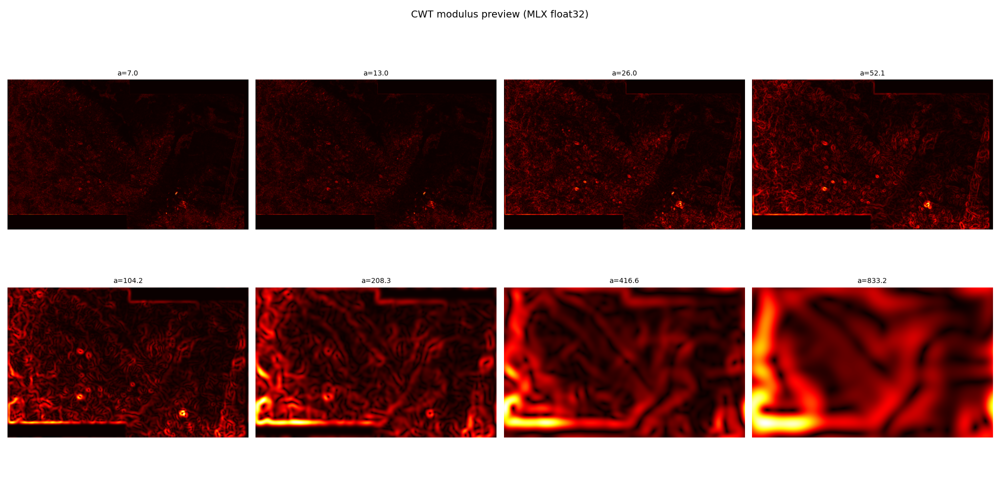

In [32]:
# Cell 4 - Quick scalogram preview (dx, dy only — fast)
n_oct = 7
n_vox = 10
scales = compute_scales(n_oct, n_vox)
print(f'{len(scales)} scales: [{scales[0]:.1f}, {scales[-1]:.1f}]')

preview = cwt_2d_f32(image, scales, pad=32, derivs='first')

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
ds = max(1, ly // 500)
show_idx = np.linspace(0, len(scales)-1, 8, dtype=int)
for ax, idx in zip(axes.flat, show_idx):
    ax.imshow(preview['mod'][idx, ::ds, ::ds], origin='lower', cmap='hot', rasterized=True)
    ax.set_title(f'a={scales[idx]:.1f}', fontsize=10)
    ax.axis('off')
plt.suptitle('CWT modulus preview (MLX float32)', fontsize=14)
plt.tight_layout()
plt.show()

In [6]:
# Cell 5 - Interactive crop selection
from ipywidgets import interact, IntRangeSlider, Layout

mid = len(scales) // 2
ds_c = max(1, max(ly, lx) // 600)

def show_crop(y_range, x_range):
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    axes[0].imshow(image[::ds_c, ::ds_c], origin='lower', cmap='RdBu_r', rasterized=True)
    rect = plt.Rectangle((x_range[0]//ds_c, y_range[0]//ds_c),
                          (x_range[1]-x_range[0])//ds_c,
                          (y_range[1]-y_range[0])//ds_c,
                          fill=False, edgecolor='lime', linewidth=2)
    axes[0].add_patch(rect)
    crop_preview = preview['mod'][mid, y_range[0]:y_range[1]:ds_c, x_range[0]:x_range[1]:ds_c]
    axes[1].imshow(crop_preview, origin='lower', cmap='hot', rasterized=True)
    axes[1].set_title(f'|W| at scale {scales[mid]:.1f}')
    plt.suptitle(f'Crop: {y_range[1]-y_range[0]} x {x_range[1]-x_range[0]}')
    plt.tight_layout()
    plt.show()

interact(show_crop,
         y_range=IntRangeSlider(value=[100, ly-100], min=0, max=ly, step=16,
                                description='Y:', layout=Layout(width='80%')),
         x_range=IntRangeSlider(value=[100, lx-100], min=0, max=lx, step=16,
                                description='X:', layout=Layout(width='80%')))

interactive(children=(IntRangeSlider(value=(100, 2929), description='Y:', layout=Layout(width='80%'), max=3029…

<function __main__.show_crop(y_range, x_range)>

In [45]:
# Cell 6 - Full CWT on crop (all 9 derivatives for follow method)
y0, y1 = 304, 1920    # <-- adjust from sliders
x0, x1 = 2656, 3984   # <-- adjust from sliders

crop_image = image[y0:y1, x0:x1].copy()
print(f'Crop: {crop_image.shape}, dtype={crop_image.dtype}')

# Full CWT with all 9 derivatives (MLX GPU, float32)
deriv = cwt_2d_f32(crop_image, scales, pad=32, derivs='all')

print(f'\nDerivatives computed: {[k for k in deriv if k not in ("mod","arg")]}')
print(f'dtype: {deriv["dx"].dtype}')
print(f'mod range: [{deriv["mod"].min():.6f}, {deriv["mod"].max():.6f}]')

Crop: (1616, 1328), dtype=float32
  Scale 0/69: a=7.0, mod range [0.0000, 0.0388]
  Scale 7/69: a=11.3, mod range [0.0000, 0.0450]
  Scale 14/69: a=18.4, mod range [0.0000, 0.0434]
  Scale 21/69: a=29.9, mod range [0.0000, 0.0316]
  Scale 28/69: a=48.6, mod range [0.0000, 0.0300]
  Scale 35/69: a=78.9, mod range [0.0000, 0.0243]
  Scale 42/69: a=128.2, mod range [0.0000, 0.0182]
  Scale 49/69: a=208.3, mod range [0.0000, 0.0077]
  Scale 56/69: a=338.4, mod range [0.0000, 0.0048]
  Scale 63/69: a=549.7, mod range [0.0000, 0.0040]
  Scale 69/69: a=833.2, mod range [0.0000, 0.0033]

Derivatives computed: ['dx', 'dy', 'dxx', 'dxy', 'dyy', 'dxxx', 'dxxy', 'dxyy', 'dyyy']
dtype: float32
mod range: [0.000000, 0.045082]


## xsm.hsearch(ext)
## xsm.smooth_chains(ext)  removes modulus dips along chains
## xsm.ssm(ext)

## Alternatively, if you want it in the xsm.chain() call, you can add smooth=True to chaining.py; as a separate call, you have full control over when to apply the smoothing 

In [46]:
# Cell 7 - Extrema detection via xsmurf C
#
# Two methods:
#   'follow'  = kapa/kapap zero-crossing (xsmurf default, 9 derivatives)
#   'wtmm2d'  = bilinear NMS (fast, only dx/dy)

EXTREMA_METHOD = 'follow'  # <-- change to 'wtmm2d' for NMS

ext_images = []
mod_images = []  # keep for visualization
arg_images = []

for i, scale in enumerate(scales):
    if EXTREMA_METHOD == 'follow':
        # Compute kapa/kapap from all 9 derivatives (pure numpy, float32)
        kapa = gkapa_numpy(
            deriv['dx'][i], deriv['dy'][i],
            deriv['dxx'][i], deriv['dxy'][i], deriv['dyy'][i])
        kapap = gkapap_numpy(
            deriv['dx'][i], deriv['dy'][i],
            deriv['dxx'][i], deriv['dxy'][i], deriv['dyy'][i],
            deriv['dxxx'][i], deriv['dxxy'][i], deriv['dxyy'][i], deriv['dyyy'][i])
        
        # Wrap as XImage and call xsmurf's C follow method
        kapa_img = xsm.XImage.from_numpy(kapa)
        kapap_img = xsm.XImage.from_numpy(kapap)
        mod_img = xsm.XImage.from_numpy(deriv['mod'][i])
        arg_img = xsm.XImage.from_numpy(deriv['arg'][i])
        
        ext = xsm.find_extrema_follow(kapa_img, kapap_img, mod_img, arg_img,
                                       scale, thresh=1e-6)
        mod_images.append(deriv['mod'][i])
        arg_images.append(deriv['arg'][i])
        
    elif EXTREMA_METHOD == 'wtmm2d':
        # Wrap dx, dy as XImage — wtmm2d computes mod/arg/NMS internally in C
        dx_img = xsm.XImage.from_numpy(deriv['dx'][i])
        dy_img = xsm.XImage.from_numpy(deriv['dy'][i])
        ext, mod_out, arg_out = xsm.wtmm2d(dx_img, dy_img, scale, thresh=1e-6)
        mod_images.append(mod_out.to_numpy())
        arg_images.append(arg_out.to_numpy())
    
    ext_images.append(ext)
    if i % max(1, len(scales) // 10) == 0 or i == len(scales) - 1:
        print(f'  Scale {i}: a={scale:.1f}, {ext.extr_nb} extrema')

print(f'\nMethod: {EXTREMA_METHOD}')
print(f'Total: {sum(e.extr_nb for e in ext_images)} extrema across {len(scales)} scales')

  Scale 0: a=7.0, 417842 extrema
  Scale 7: a=11.3, 263434 extrema
  Scale 14: a=18.4, 162740 extrema
  Scale 21: a=29.9, 101962 extrema
  Scale 28: a=48.6, 64210 extrema
  Scale 35: a=78.9, 42052 extrema
  Scale 42: a=128.2, 26913 extrema
  Scale 49: a=208.3, 15372 extrema
  Scale 56: a=338.4, 8795 extrema
  Scale 63: a=549.7, 4831 extrema
  Scale 69: a=833.2, 4257 extrema

Method: follow
Total: 6412288 extrema across 70 scales


  Octave 0 - voice 0 - scale 6.9767 (0)
  Octave 0 - voice 1 - scale 7.4775 (1)
  Octave 0 - voice 2 - scale 8.0142 (2)
  Octave 0 - voice 3 - scale 8.5894 (3)
  Octave 0 - voice 4 - scale 9.2059 (4)
  Octave 0 - voice 5 - scale 9.8666 (5)
  Octave 0 - voice 6 - scale 10.5748 (6)
  Octave 0 - voice 7 - scale 11.3338 (7)
  Octave 0 - voice 8 - scale 12.1472 (8)
  Octave 0 - voice 9 - scale 13.0191 (9)
  Octave 1 - voice 0 - scale 13.9535 (10)
  Octave 1 - voice 1 - scale 14.9550 (11)
  Octave 1 - voice 2 - scale 16.0283 (12)
  Octave 1 - voice 3 - scale 17.1788 (13)
  Octave 1 - voice 4 - scale 18.4117 (14)
  Octave 1 - voice 5 - scale 19.7332 (15)
  Octave 1 - voice 6 - scale 21.1495 (16)
  Octave 1 - voice 7 - scale 22.6675 (17)
  Octave 1 - voice 8 - scale 24.2944 (18)
  Octave 1 - voice 9 - scale 26.0381 (19)
  Octave 2 - voice 0 - scale 27.9070 (20)
  Octave 2 - voice 1 - scale 29.9100 (21)
  Octave 2 - voice 2 - scale 32.0567 (22)
  Octave 2 - voice 3 - scale 34.3575 (23)
  Octave

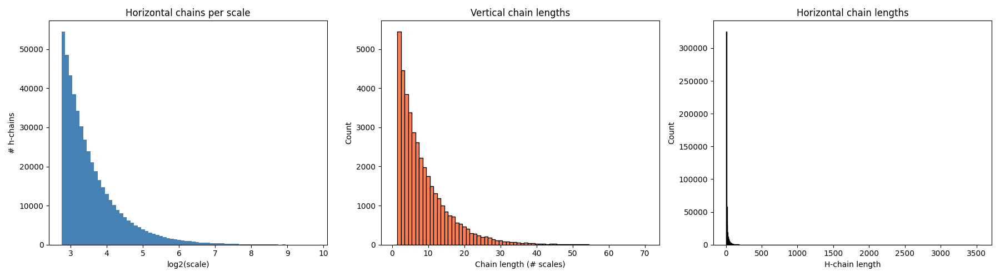

In [47]:
# Cell 8 - Chain (xsmurf C: hsearch -> ssm -> vchain)
xsm.chain(ext_images, a_min=1.0, n_oct=n_oct, n_vox=n_vox)
chains = xsm.extract_vertical_chains(ext_images, scales)
print(f'{len(chains)} vertical chains')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Horizontal chains per scale
n_lines = [ext.nb_of_lines for ext in ext_images]
axes[0].bar(np.log2(scales), n_lines, width=0.1, color='steelblue')
axes[0].set(xlabel='log2(scale)', ylabel='# h-chains', title='Horizontal chains per scale')

# Vertical chain lengths
vc_lens = [len(ch['mod']) for ch in chains]
axes[1].hist(vc_lens, bins=np.arange(0.5, len(scales)+1.5, 1), color='coral', edgecolor='k')
axes[1].set(xlabel='Chain length (# scales)', ylabel='Count', title='Vertical chain lengths')

# H-chain length distribution
all_hlen = []
for ext in ext_images:
    for line in ext.get_lines():
        all_hlen.append(line['size'])
if all_hlen:
    axes[2].hist(all_hlen, bins=500, color='mediumpurple', edgecolor='k')
axes[2].set(xlabel='H-chain length', ylabel='Count', title='Horizontal chain lengths')

plt.tight_layout()
plt.show()

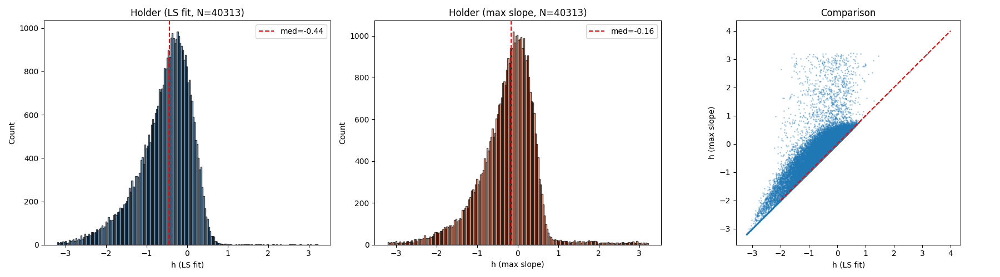

In [48]:
# Cell 9 - Holder exponents
holders_fit = xsm.compute_holder_exponents(chains)
holders_slope = xsm.compute_holder_local_slope(chains, method='max')
h_fit = np.array([h['h'] for h in holders_fit])
h_slope = np.array([h['h'] for h in holders_slope])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(h_fit[np.isfinite(h_fit)], bins=200, color='steelblue', edgecolor='k', alpha=0.7)
axes[0].set(xlabel='h (LS fit)', ylabel='Count', title=f'Holder (LS fit, N={len(h_fit)})')
axes[0].axvline(np.nanmedian(h_fit), color='red', ls='--', label=f'med={np.nanmedian(h_fit):.2f}')
axes[0].legend()

axes[1].hist(h_slope[np.isfinite(h_slope)], bins=200, color='coral', edgecolor='k', alpha=0.7)
axes[1].set(xlabel='h (max slope)', ylabel='Count', title=f'Holder (max slope, N={len(h_slope)})')
axes[1].axvline(np.nanmedian(h_slope), color='red', ls='--', label=f'med={np.nanmedian(h_slope):.2f}')
axes[1].legend()

min_len = min(len(h_fit), len(h_slope))
axes[2].scatter(h_fit[:min_len], h_slope[:min_len], s=1, alpha=0.3)
axes[2].plot([-2, 4], [-2, 4], 'r--')
axes[2].set(xlabel='h (LS fit)', ylabel='h (max slope)', title='Comparison')
axes[2].set_aspect('equal')

plt.tight_layout()
plt.show()

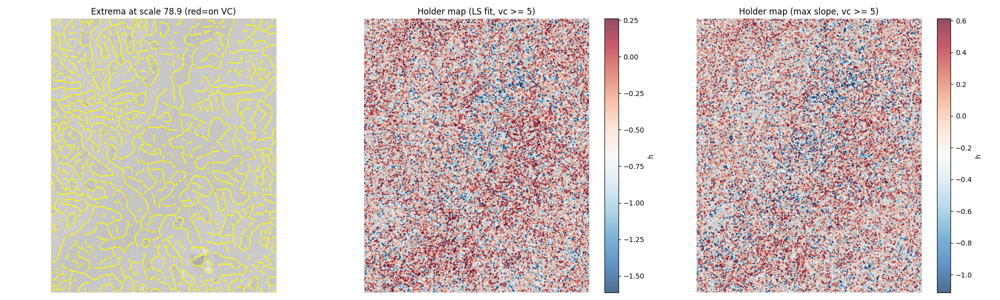

In [49]:
# Cell 10 - Skeleton visualization
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
ds_sk = max(1, crop_image.shape[0] // 800)

for ax in axes:
    ax.imshow(crop_image[::ds_sk, ::ds_sk], origin='lower', cmap='gray',
              alpha=0.5, rasterized=True)

# Extrema at mid scale (red = on vertical chain)
mid_idx = len(scales) // 2
data_mid = ext_images[mid_idx].get_extrema_arrays()
on_vc = ext_images[mid_idx].get_on_vertical_chain()
axes[0].scatter(data_mid['x'][::2] / ds_sk, data_mid['y'][::2] / ds_sk,
                c=np.where(on_vc[::2], 'red', 'yellow'), s=0.5, alpha=0.5)
axes[0].set_title(f'Extrema at scale {scales[mid_idx]:.1f} (red=on VC)')

# Holder map (LS fit, long chains only)
min_vc_len = 5
long_chains = [(h, ch) for h, ch in zip(holders_fit, chains) if ch['mod'].shape[0] >= min_vc_len]
if long_chains:
    xs = np.array([h['x'] for h, _ in long_chains]) / ds_sk
    ys = np.array([h['y'] for h, _ in long_chains]) / ds_sk
    hs = np.array([h['h'] for h, _ in long_chains])
    vmin, vmax = np.nanpercentile(hs, [5, 95])
    sc = axes[1].scatter(xs, ys, c=hs, cmap='RdBu_r', s=2, vmin=vmin, vmax=vmax, alpha=0.7)
    plt.colorbar(sc, ax=axes[1], label='h')
axes[1].set_title(f'Holder map (LS fit, vc >= {min_vc_len})')

# Holder map (max slope)
long_chains_s = [(h, ch) for h, ch in zip(holders_slope, chains) if ch['mod'].shape[0] >= min_vc_len]
if long_chains_s:
    xs_s = np.array([h['x'] for h, _ in long_chains_s]) / ds_sk
    ys_s = np.array([h['y'] for h, _ in long_chains_s]) / ds_sk
    hs_s = np.array([h['h'] for h, _ in long_chains_s])
    vmin_s, vmax_s = np.nanpercentile(hs_s, [5, 95])
    sc2 = axes[2].scatter(xs_s, ys_s, c=hs_s, cmap='RdBu_r', s=2, vmin=vmin_s, vmax=vmax_s, alpha=0.7)
    plt.colorbar(sc2, ax=axes[2], label='h')
axes[2].set_title(f'Holder map (max slope, vc >= {min_vc_len})')

for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.show()

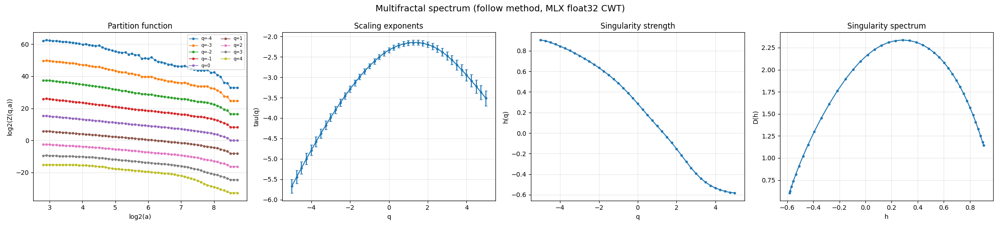

In [50]:
# Cell 11 - Partition function and D(h) spectrum
spectra = xsm.compute_spectra(ext_images, scales)

fig, axes = plt.subplots(1, 4, figsize=(22, 5))

# Z(q,a)
q_show = np.arange(-4, 5, 1.0)
for q in q_show:
    qi = np.argmin(np.abs(spectra['q_list'] - q))
    axes[0].plot(spectra['log2_scales'], spectra['log2_Z'][qi], '.-',
                 label=f'q={q:.0f}', lw=1)
axes[0].set(xlabel='log2(a)', ylabel='log2(Z(q,a))', title='Partition function')
axes[0].legend(fontsize=7, ncol=2)
axes[0].grid(True, alpha=0.3)

# tau(q)
axes[1].errorbar(spectra['q_list'], spectra['tau'], yerr=spectra['tau_err'],
                 fmt='.-', capsize=2)
axes[1].set(xlabel='q', ylabel='tau(q)', title='Scaling exponents')
axes[1].grid(True, alpha=0.3)

# h(q)
axes[2].plot(spectra['q_list'], spectra['h'], '.-')
axes[2].set(xlabel='q', ylabel='h(q)', title='Singularity strength')
axes[2].grid(True, alpha=0.3)

# D(h)
valid = np.isfinite(spectra['D']) & np.isfinite(spectra['h'])
axes[3].plot(spectra['h'][valid], spectra['D'][valid], '.-')
axes[3].set(xlabel='h', ylabel='D(h)', title='Singularity spectrum')
axes[3].grid(True, alpha=0.3)

plt.suptitle(f'Multifractal spectrum ({EXTREMA_METHOD} method, MLX float32 CWT)', fontsize=14)
plt.tight_layout()
plt.show()

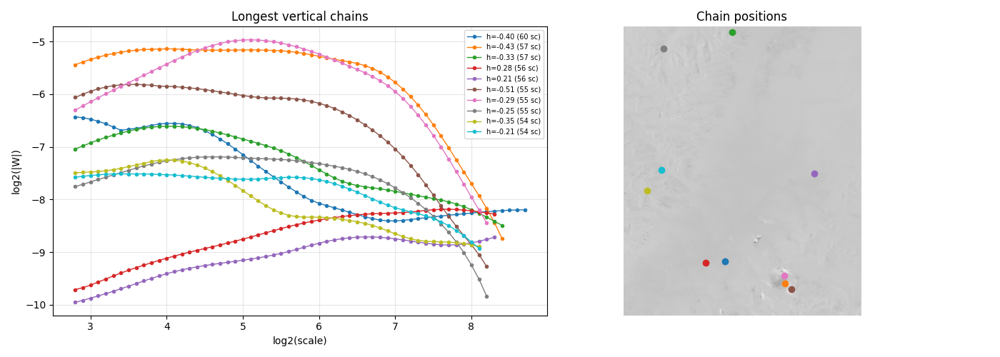

In [51]:
# Cell 12 - Example maxima chains: log|W| vs log(a)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sorted_chains = sorted(zip(holders_fit, chains),
                        key=lambda x: len(x[1]['mod']), reverse=True)

colors = plt.cm.tab10(np.linspace(0, 1, 10))
for i, (h_info, ch) in enumerate(sorted_chains[:10]):
    axes[0].plot(ch['log2_scales'], ch['log2_mod'], '.-', color=colors[i],
                 label=f'h={h_info["h"]:.2f} ({len(ch["mod"])} sc)', lw=1)

axes[0].set(xlabel='log2(scale)', ylabel='log2(|W|)',
            title='Longest vertical chains')
axes[0].legend(fontsize=7)
axes[0].grid(True, alpha=0.3)

# Show chain positions
ds_ch = max(1, crop_image.shape[0] // 600)
axes[1].imshow(crop_image[::ds_ch, ::ds_ch], origin='lower', cmap='gray',
               alpha=0.5, rasterized=True)
for i, (h_info, ch) in enumerate(sorted_chains[:10]):
    axes[1].plot(ch['x'][0] / ds_ch, ch['y'][0] / ds_ch, 'o',
                 color=colors[i], markersize=6)
axes[1].set_title('Chain positions')
axes[1].axis('off')

plt.tight_layout()
plt.show()

In [60]:
# Cell 13 - Precompute flat arrays for fast interactive viewer
import time

t0 = time.time()

h_fit_lookup = {(int(hd['x']), int(hd['y'])): hd['h'] for hd in holders_fit}
h_slope_lookup = {(int(hd['x']), int(hd['y'])): hd['h'] for hd in holders_slope}

# Build global lookup: (si, x, y) -> (vc_len, anchor_key)
chain_lookup = {}
for ch in chains:
    vc_len = len(ch['mod'])
    if vc_len == 0:
        continue
    anchor_key = (int(ch['x'][0]), int(ch['y'][0]))
    n_sc = min(vc_len, len(scales))
    for si in range(n_sc):
        key = (si, int(ch['x'][si]), int(ch['y'][si]))
        chain_lookup[key] = (vc_len, anchor_key)

print(f"Built chain lookup with {len(chain_lookup)} entries in {time.time()-t0:.1f}s")

all_xs, all_ys, all_args, all_mods = [], [], [], []
all_scale_idx, all_hchain_len = [], []
all_line_h_fit, all_line_h_slope = [], []
all_line_max_vc, all_point_vc = [], []

for si in range(len(scales)):
    ext = ext_images[si]
    lines = ext.get_lines()
    data = ext.get_extrema_arrays()
    lx_ext = ext.lx

    pos = data['pos'].astype(np.int64)
    xs_all = data['x'].astype(np.int32)
    ys_all = data['y'].astype(np.int32)
    args_all = data['arg'].astype(np.float32)
    mods_all = data['mod'].astype(np.float32)

    pos_to_arg = dict(zip(pos, args_all))
    pos_to_mod = dict(zip(pos, mods_all))

    pos_to_vc = {}
    on_vc = ext.get_on_vertical_chain()

    for j_ext in range(ext.extr_nb):
        p = int(pos[j_ext])
        if on_vc[j_ext]:
            key = (si, int(xs_all[j_ext]), int(ys_all[j_ext]))
            vc_len = chain_lookup.get(key, (0, None))[0]
        else:
            vc_len = 0
        pos_to_vc[p] = vc_len

    for line in lines:
        positions = np.asarray(line['extrema_pos'], dtype=np.int64)
        xs = (positions % lx_ext).astype(np.int32)
        ys = (positions // lx_ext).astype(np.int32)
        args = np.array([pos_to_arg.get(int(p), 0.0) for p in positions], dtype=np.float32)
        mods = np.array([pos_to_mod.get(int(p), 0.0) for p in positions], dtype=np.float32)
        point_vcs = np.array([pos_to_vc.get(int(p), 0) for p in positions], dtype=np.int32)

        n_pts = len(xs)
        line_max_vc = int(point_vcs.max()) if n_pts > 0 else 0
        line_h_fit = np.nan
        line_h_slope = np.nan

        if line_max_vc > 0:
            best_idx = int(np.argmax(point_vcs))
            px, py = int(xs[best_idx]), int(ys[best_idx])
            vc_len, anchor_key = chain_lookup.get((si, px, py), (0, None))
            if anchor_key is not None:
                line_h_fit = h_fit_lookup.get(anchor_key, np.nan)
                line_h_slope = h_slope_lookup.get(anchor_key, np.nan)

        all_xs.append(xs)
        all_ys.append(ys)
        all_args.append(args)
        all_mods.append(mods)
        all_scale_idx.append(np.full(n_pts, si, dtype=np.int32))
        all_hchain_len.append(np.full(n_pts, line['size'], dtype=np.int32))
        all_line_h_fit.append(np.full(n_pts, line_h_fit, dtype=np.float32))
        all_line_h_slope.append(np.full(n_pts, line_h_slope, dtype=np.float32))
        all_line_max_vc.append(np.full(n_pts, line_max_vc, dtype=np.int32))
        all_point_vc.append(point_vcs)

flat_x = np.concatenate(all_xs) if all_xs else np.array([], dtype=np.int32)
flat_y = np.concatenate(all_ys) if all_ys else np.array([], dtype=np.int32)
flat_arg = np.concatenate(all_args) if all_args else np.array([], dtype=np.float32)
flat_mod = np.concatenate(all_mods) if all_mods else np.array([], dtype=np.float32)
flat_si = np.concatenate(all_scale_idx) if all_scale_idx else np.array([], dtype=np.int32)
flat_hlen = np.concatenate(all_hchain_len) if all_hchain_len else np.array([], dtype=np.int32)
flat_h_fit = np.concatenate(all_line_h_fit) if all_line_h_fit else np.array([], dtype=np.float32)
flat_h_slope = np.concatenate(all_line_h_slope) if all_line_h_slope else np.array([], dtype=np.float32)
flat_line_max_vc = np.concatenate(all_line_max_vc) if all_line_max_vc else np.array([], dtype=np.int32)
flat_point_vc = np.concatenate(all_point_vc) if all_point_vc else np.array([], dtype=np.int32)

print(f"Precomputed {len(flat_x)} points from {len(all_xs)} lines in {time.time()-t0:.1f}s")
print(f"  {(flat_line_max_vc > 0).sum()} points on lines with vc anchors")

Built chain lookup with 352293 entries in 0.3s
Precomputed 6412288 points from 486584 lines in 18.8s
  5144513 points on lines with vc anchors


In [63]:
# Cell 14 - Interactive extrema viewer
# Horizontal chains as continuous lines, WTMMM arrows colored by scale
from ipywidgets import interact, IntSlider, IntRangeSlider, Checkbox, Dropdown, FloatSlider, Layout
from matplotlib.colors import Normalize
from matplotlib.collections import LineCollection

crop_f = crop_image.astype(np.float64)
crop_lin = crop_f.copy()
crop_log = np.log1p(crop_f - crop_f.min())

def hist_eq(img):
    flat = img.ravel()
    hist, bins = np.histogram(flat[np.isfinite(flat)], bins=1000)
    cdf = hist.cumsum().astype(np.float64)
    cdf = cdf / cdf[-1]
    return np.interp(flat, bins[:-1], cdf).reshape(img.shape)

crop_heq = hist_eq(crop_f)
stretch_dict = {'Linear': crop_lin, 'Log': crop_log, 'Histogram EQ': crop_heq}

ds_bg = max(1, max(crop_image.shape) // 800)

vc_x_arr = np.array([int(ch['x'][0]) for ch in chains], dtype=np.int32)
vc_y_arr = np.array([int(ch['y'][0]) for ch in chains], dtype=np.int32)
vc_len_arr = np.array([len(ch['mod']) for ch in chains], dtype=np.int32)
vc_h_fit_arr = np.array(
    [h_fit_lookup.get((int(ch['x'][0]), int(ch['y'][0])), np.nan) for ch in chains], dtype=np.float32)
vc_h_slope_arr = np.array(
    [h_slope_lookup.get((int(ch['x'][0]), int(ch['y'][0])), np.nan) for ch in chains], dtype=np.float32)

# Precompute line segments per scale for LineCollection rendering
lines_by_scale = []
lines_hfit_by_scale = []
lines_hslope_by_scale = []
lines_maxvc_by_scale = []

for si in range(len(scales)):
    ext = ext_images[si]
    line_list = ext.get_lines()
    lx_ext = ext.lx
    segs, seg_hfit, seg_hslope, seg_maxvc = [], [], [], []
    for line in line_list:
        positions = np.asarray(line['extrema_pos'], dtype=np.int64)
        if len(positions) < 2:
            continue
        xs = (positions % lx_ext).astype(np.float64)
        ys = (positions // lx_ext).astype(np.float64)
        segs.append(np.column_stack([xs, ys]))
        max_vc, best_hfit, best_hslope = 0, np.nan, np.nan
        for j in range(len(positions)):
            info = chain_lookup.get((si, int(xs[j]), int(ys[j])), (0, None))
            if info[0] > max_vc:
                max_vc = info[0]
                if info[1] is not None:
                    best_hfit = h_fit_lookup.get(info[1], np.nan)
                    best_hslope = h_slope_lookup.get(info[1], np.nan)
        seg_hfit.append(best_hfit)
        seg_hslope.append(best_hslope)
        seg_maxvc.append(max_vc)
    lines_by_scale.append(segs)
    lines_hfit_by_scale.append(np.array(seg_hfit, dtype=np.float32))
    lines_hslope_by_scale.append(np.array(seg_hslope, dtype=np.float32))
    lines_maxvc_by_scale.append(np.array(seg_maxvc, dtype=np.int32))

# Precompute WTMMM arrows per scale (only points on vertical chains)
wtmmm_by_scale = []
for si in range(len(scales)):
    ext = ext_images[si]
    data = ext.get_extrema_arrays()
    on_vc = ext.get_on_vertical_chain()
    if ext.extr_nb == 0:
        wtmmm_by_scale.append({'x': np.array([]), 'y': np.array([]),
                                'mod': np.array([]), 'arg': np.array([])})
        continue
    m = on_vc.astype(bool)
    wtmmm_by_scale.append({
        'x': data['x'][m].astype(np.float64),
        'y': data['y'][m].astype(np.float64),
        'mod': data['mod'][m],
        'arg': data['arg'][m],
    })

print(f"Precomputed {sum(len(s) for s in lines_by_scale)} line segments, "
      f"{sum(len(w['x']) for w in wtmmm_by_scale)} WTMMM arrows")

def robust_limits(vals, lo=5, hi=95, default=(-1, 1)):
    return (np.percentile(vals, lo), np.percentile(vals, hi)) if len(vals) > 0 else default

scale_cmap = plt.cm.rainbow
scale_norm = Normalize(vmin=0, vmax=len(scales)-1)

def draw_fast(scale_range, min_hchain, min_vc, min_h, h_filter_method,
              color_by, cmap_name, show_mode, stretch, show_bg, line_width,
              arrow_scale, log2_arrows):
    fig, ax = plt.subplots(figsize=(14, 10))
    if show_bg:
        bg = stretch_dict[stretch]
        ax.imshow(bg[::ds_bg, ::ds_bg], origin='lower', cmap='gray', rasterized=True,
                  extent=[0, crop_image.shape[1], 0, crop_image.shape[0]], alpha=0.6)
        ax.set_facecolor('black')
    else:
        ax.set_facecolor('white')

    si_lo, si_hi = scale_range
    si_range = range(si_lo, si_hi + 1)

    if show_mode in ('Horizontal chains', 'Chains + arrows'):
        n_pts = 0
        for si in si_range:
            segs = lines_by_scale[si]
            hfit = lines_hfit_by_scale[si]
            hslope = lines_hslope_by_scale[si]
            maxvc = lines_maxvc_by_scale[si]
            if not segs:
                continue

            keep = np.ones(len(segs), dtype=bool)
            for j, seg in enumerate(segs):
                if len(seg) < min_hchain:
                    keep[j] = False
            if min_vc > 0:
                keep &= (maxvc >= min_vc)
            if min_h > -4.9:
                h_ref = hfit if h_filter_method == 'LS fit' else hslope
                keep &= (h_ref >= min_h) | np.isnan(h_ref)

            filtered_segs = [segs[j] for j in range(len(segs)) if keep[j]]
            if not filtered_segs:
                continue

            if color_by in ('h (LS fit)', 'h (max slope)'):
                h_vals = hfit[keep] if color_by == 'h (LS fit)' else hslope[keep]
                valid_h = h_vals[np.isfinite(h_vals)]
                vmin, vmax = robust_limits(valid_h, 5, 95) if len(valid_h) > 0 else (-1, 1)
                lc = LineCollection(filtered_segs, cmap=cmap_name,
                                    norm=Normalize(vmin=vmin, vmax=vmax),
                                    linewidths=line_width, alpha=1)
                lc.set_array(h_vals)
                ax.add_collection(lc)
                if si == si_range[-1]:
                    plt.colorbar(lc, ax=ax, label=color_by, shrink=0.6)
            else:
                sc_color = scale_cmap(scale_norm(si))
                lc = LineCollection(filtered_segs, colors=[sc_color]*len(filtered_segs),
                                    linewidths=line_width, alpha=1)
                ax.add_collection(lc)

            n_pts += sum(len(s) for s in filtered_segs)

        if show_mode == 'Chains + arrows':
            for si in si_range:
                w = wtmmm_by_scale[si]
                if len(w['x']) == 0:
                    continue
                if log2_arrows:
                    log_mod = np.log2(np.maximum(w['mod'], 1e-30))
                    log_min = log_mod.min()
                    log_range = log_mod.max() - log_min
                    mod_norm = (log_mod - log_min) / (log_range + 1e-30)
                else:
                    mod_max = w['mod'].max()
                    mod_norm = w['mod'] / (mod_max + 1e-30)
                dx_a = np.cos(w['arg']) * mod_norm * arrow_scale
                dy_a = np.sin(w['arg']) * mod_norm * arrow_scale
                sc_color = scale_cmap(scale_norm(si))
                max_arrows = min(8000, len(w['x']))
                step_q = max(1, len(w['x']) // max_arrows)
                ax.quiver(w['x'][::step_q], w['y'][::step_q],
                          dx_a[::step_q], dy_a[::step_q],
                          color=sc_color, scale_units='xy', scale=1,
                          width=0.003, headwidth=4, headlength=3,
                          headaxislength=2.5, alpha=0.9, zorder=5)

        if color_by == 'scale':
            sm = plt.cm.ScalarMappable(norm=scale_norm, cmap=scale_cmap)
            sm.set_array([])
            plt.colorbar(sm, ax=ax, label='scale index', shrink=0.6)

    else:  # VC origin points
        vc_mask = (vc_len_arr >= max(min_vc, 2))
        if min_h > -4.9:
            h_ref = vc_h_fit_arr if h_filter_method == 'LS fit' else vc_h_slope_arr
            vc_mask &= (h_ref >= min_h) | np.isnan(h_ref)
        c_raw = vc_h_fit_arr if color_by in ('h (LS fit)',) else vc_h_slope_arr
        c_vals = c_raw[vc_mask]; valid = ~np.isnan(c_vals)
        x_m = vc_x_arr[vc_mask][valid]; y_m = vc_y_arr[vc_mask][valid]; c_vals = c_vals[valid]
        vmin, vmax = robust_limits(c_vals, 5, 95)
        if len(x_m) > 50000:
            step = int(np.ceil(len(x_m) / 50000))
            x_m, y_m, c_vals = x_m[::step], y_m[::step], c_vals[::step]
        if len(x_m) > 0:
            sc = ax.scatter(x_m, y_m, c=c_vals, s=8, cmap=cmap_name,
                            vmin=vmin, vmax=vmax, rasterized=True)
            plt.colorbar(sc, ax=ax, label='h', shrink=0.6)
        n_pts = len(x_m)

    scope = f'scales {si_lo}-{si_hi} (a={scales[si_lo]:.1f}-{scales[si_hi]:.1f})'
    ax.set_title(f'{show_mode} | {color_by} -- {n_pts} pts ({scope})')
    ax.set_xlim(0, crop_image.shape[1]); ax.set_ylim(0, crop_image.shape[0])
    ax.set_aspect('equal'); plt.tight_layout(); plt.show()

interact(
    draw_fast,
    scale_range=IntRangeSlider(value=[len(scales)//2, len(scales)//2], min=0, max=len(scales)-1,
                               description='Scale range:', layout=Layout(width='70%'),
                               continuous_update=False),
    min_hchain=IntSlider(value=10, min=1, max=500, step=5,
                         description='Min h-chain:', layout=Layout(width='60%'), continuous_update=False),
    min_vc=IntSlider(value=0, min=0, max=len(scales), step=1,
                     description='Min vc on line:', layout=Layout(width='60%'), continuous_update=False),
    min_h=FloatSlider(value=-5.0, min=-5.0, max=5.0, step=0.1,
                      description='Min h:', layout=Layout(width='60%'), continuous_update=False),
    h_filter_method=Dropdown(options=['Max slope', 'LS fit'], value='Max slope', description='h filter on:'),
    color_by=Dropdown(options=['scale', 'h (LS fit)', 'h (max slope)'],
                      value='scale', description='Color by:'),
    cmap_name=Dropdown(options=['RdBu_r', 'coolwarm', 'seismic', 'PiYG', 'viridis', 'plasma', 'turbo'],
                       value='RdBu_r', description='Colormap:'),
    show_mode=Dropdown(options=['Chains + arrows', 'Horizontal chains', 'VC origin points'],
                       value='Chains + arrows', description='Show:'),
    stretch=Dropdown(options=['Linear', 'Log', 'Histogram EQ'], value='Linear', description='Stretch:'),
    show_bg=Checkbox(value=True, description='Show band image'),
    line_width=FloatSlider(value=0.5, min=0.1, max=3.0, step=0.1,
                           description='Line width:', layout=Layout(width='60%'), continuous_update=False),
    arrow_scale=FloatSlider(value=100.0, min=1.0, max=500.0, step=1.0,
                            description='Arrow scale:', layout=Layout(width='60%'), continuous_update=False),
    log2_arrows=Checkbox(value=False, description='log2(mod) arrows'));

Precomputed 368188 line segments, 352293 WTMMM arrows


interactive(children=(IntRangeSlider(value=(35, 35), continuous_update=False, description='Scale range:', layo…

In [61]:
# Cell 15 - Filter chains for partition function
filt_min_vc = 0
filt_min_hchain = 10
filt_min_h = -5
filt_h_method = 'max_slope'  # 'ls_fit' or 'max_slope'

filtered_chains = []
for ch in chains:
    key = (int(ch['x'][0]), int(ch['y'][0]))
    vc_len = len(ch['mod'])
    if vc_len < filt_min_vc:
        continue
    if filt_min_h > -4.9:
        h_val = h_fit_lookup.get(key, np.nan) if filt_h_method == 'ls_fit' else h_slope_lookup.get(key, np.nan)
        if np.isnan(h_val) or h_val < filt_min_h:
            continue
    filtered_chains.append(ch)

print(f"Filtered: {len(filtered_chains)} / {len(chains)} chains "
      f"(min_vc={filt_min_vc}, min_h={filt_min_h}, {filt_h_method})")

filtered_positions = set()
for ch in filtered_chains:
    n_ch = len(ch['mod'])
    for si in range(min(n_ch, len(scales))):
        filtered_positions.add((si, int(ch['x'][si]), int(ch['y'][si])))
print(f"Total filtered vc points: {len(filtered_positions)}")

Filtered: 40313 / 40313 chains (min_vc=0, min_h=-5, max_slope)
Total filtered vc points: 352293


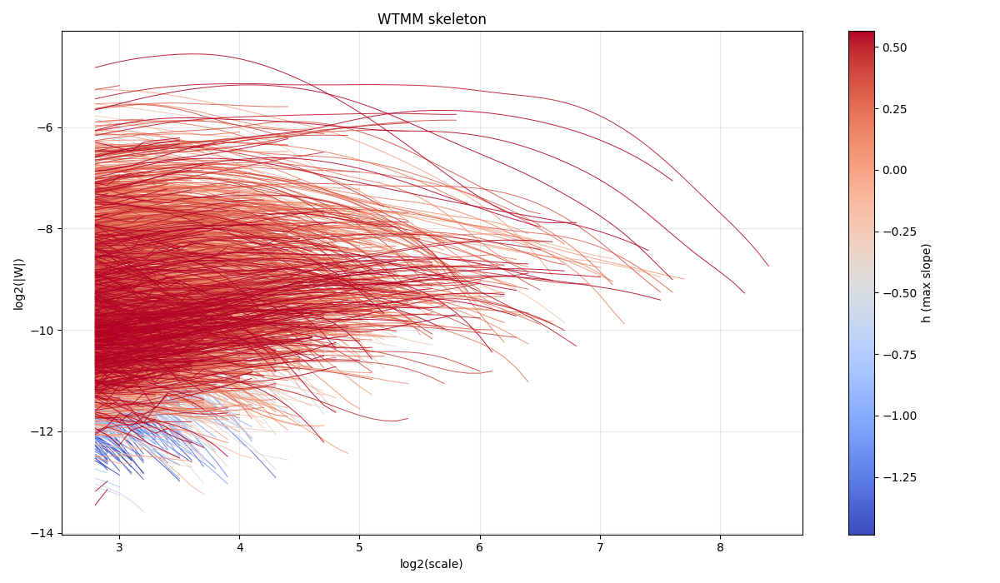

In [62]:
# Cell 16 - Skeleton plot colored by Holder exponent
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

fig, ax = plt.subplots(figsize=(12, 7))
log2_scales_arr = np.log2(scales)

plot_items = []
for ch in chains[:5000]:
    n = len(ch['mod'])
    if n < 2:
        continue
    key = (int(ch['x'][0]), int(ch['y'][0]))
    h = h_slope_lookup.get(key, np.nan)
    if not np.isfinite(h):
        continue
    log2_mod = np.log2(np.maximum(np.abs(ch['mod']), 1e-30))
    plot_items.append((h, n, log2_mod))

if plot_items:
    plot_items.sort(key=lambda t: t[0])
    h_vals = np.array([item[0] for item in plot_items])
    vmin, vmax = np.percentile(h_vals, 5), np.percentile(h_vals, 95)
    if vmin == vmax:
        vmin, vmax = np.nanmin(h_vals), np.nanmax(h_vals)
    norm = Normalize(vmin=vmin, vmax=vmax)
    cmap = plt.cm.coolwarm
    for h, n, log2_mod in plot_items:
        ax.plot(log2_scales_arr[:n], log2_mod, '-', color=cmap(norm(h)), alpha=0.9, lw=0.7)
    sm = ScalarMappable(norm=norm, cmap=cmap); sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax); cbar.set_label('h (max slope)')
else:
    print("No chains with finite Holder exponents")

ax.set(xlabel='log2(scale)', ylabel='log2(|W|)', title='WTMM skeleton')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Partition functions computed with 40313 filtered chains
  Standard: extrema per scale = [2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Chainmax: extrema per scale = [2, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


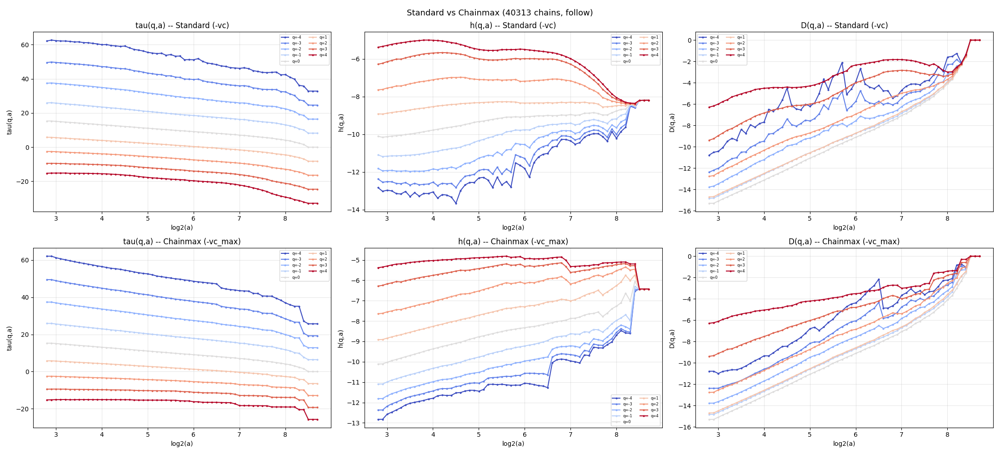

In [57]:
# Cell 17 - Partition function: standard vs chainmax comparison
import importlib, xsmurf_wrapper.partition
importlib.reload(xsmurf_wrapper.partition)
from xsmurf_wrapper.partition import compute_HD_per_scale, extract_hq_Dq_from_plateaus

q_list = np.concatenate([
    np.arange(-20, -2, .5),
    np.arange(-2, 5.1, 0.1),
    np.arange(2.5, 20, .5)
])

n_q = len(q_list)
n_scales_pf = len(scales)
STq = np.zeros((n_q, n_scales_pf), dtype=np.float64)
STqlogT = np.zeros((n_q, n_scales_pf), dtype=np.float64)

# Chainmax: running max along each filtered chain
chainmax_lookup = [{} for _ in range(n_scales_pf)]
for ch in filtered_chains:
    n_ch = len(ch['mod'])
    running_max = 0.0
    for si in range(min(n_ch, n_scales_pf)):
        m = abs(float(ch['mod'][si]))
        if m > running_max:
            running_max = m
        chainmax_lookup[si][(int(ch['x'][si]), int(ch['y'][si]))] = running_max

STq_sup = np.zeros((n_q, n_scales_pf), dtype=np.float64)
STqlogT_sup = np.zeros((n_q, n_scales_pf), dtype=np.float64)

for j, ext in enumerate(ext_images):
    data = ext.get_extrema_arrays()
    on_vc = ext.get_on_vertical_chain()
    mod_list, mod_sup_list = [], []
    for k in range(ext.extr_nb):
        if on_vc[k]:
            pos_key = (j, int(data['x'][k]), int(data['y'][k]))
            if pos_key in filtered_positions:
                m = abs(float(data['mod'][k]))
                if m > 0:
                    mod_list.append(m)
                    xy_key = (int(data['x'][k]), int(data['y'][k]))
                    m_sup = chainmax_lookup[j].get(xy_key, m)
                    mod_sup_list.append(max(m_sup, 1e-30))
    if not mod_list:
        continue
    mod = np.array(mod_list, dtype=np.float64)
    mod_sup = np.array(mod_sup_list, dtype=np.float64)
    log_mod = np.log(mod)
    log_mod_sup = np.log(mod_sup)
    for i, q in enumerate(q_list):
        mod_q = mod ** q if q != 0 else np.ones(len(mod))
        STq[i, j] = np.sum(mod_q)
        STqlogT[i, j] = np.sum(log_mod * mod_q)
        mod_q_sup = mod_sup ** q if q != 0 else np.ones(len(mod_sup))
        STq_sup[i, j] = np.sum(mod_q_sup)
        STqlogT_sup[i, j] = np.sum(log_mod_sup * mod_q_sup)

log2 = np.log(2.0)

def build_hd(STq_in, STqlogT_in):
    tau_qa = np.full((n_q, n_scales_pf), np.nan)
    h_qa = np.full((n_q, n_scales_pf), np.nan)
    D_qa = np.full((n_q, n_scales_pf), np.nan)
    valid_Z = STq_in > 0
    tau_qa[valid_Z] = np.log(STq_in[valid_Z]) / log2
    h_qa[valid_Z] = STqlogT_in[valid_Z] / (log2 * STq_in[valid_Z])
    for i, q in enumerate(q_list):
        for j_s in range(n_scales_pf):
            if STq_in[i, j_s] > 0:
                D_qa[i, j_s] = (q * STqlogT_in[i, j_s] - STq_in[i, j_s] * np.log(STq_in[i, j_s])) / \
                               (STq_in[i, j_s] * log2)
    return {'tau_qa': tau_qa, 'h_qa': h_qa, 'D_qa': D_qa,
            'STq': STq_in, 'STqlogT': STqlogT_in,
            'q_list': np.array(q_list), 'scales': np.array(scales),
            'log2_scales': np.log2(np.array(scales))}

hd = build_hd(STq, STqlogT)
hd_sup = build_hd(STq_sup, STqlogT_sup)

print(f"Partition functions computed with {len(filtered_chains)} filtered chains")
print(f"  Standard: extrema per scale = {[int(STq[n_q//2, j]) for j in range(n_scales_pf)]}")
print(f"  Chainmax: extrema per scale = {[int(STq_sup[n_q//2, j]) for j in range(n_scales_pf)]}")

fig, axes = plt.subplots(2, 3, figsize=(22, 10))
q_show = np.arange(-4, 5, 1.0)
colors = plt.cm.coolwarm(np.linspace(0, 1, len(q_show)))
for row, (hd_plot, label) in enumerate([(hd, 'Standard (-vc)'), (hd_sup, 'Chainmax (-vc_max)')]):
    for panel, key, ylabel, title in [
        (0, 'tau_qa', 'tau(q,a)', 'tau(q,a)'),
        (1, 'h_qa', 'h(q,a)', 'h(q,a)'),
        (2, 'D_qa', 'D(q,a)', 'D(q,a)')]:
        ax = axes[row, panel]
        for qi, color in zip(q_show, colors):
            idx = np.argmin(np.abs(hd_plot['q_list'] - qi))
            y = hd_plot[key][idx]; v = np.isfinite(y)
            if v.sum() > 1:
                ax.plot(hd_plot['log2_scales'][v], y[v], '.-', color=color,
                        label=f'q={qi:.0f}', ms=4)
        ax.set(xlabel='log2(a)', ylabel=ylabel, title=f'{title} -- {label}')
        ax.legend(fontsize=6, ncol=2); ax.grid(True, alpha=0.3)
plt.suptitle(f'Standard vs Chainmax ({len(filtered_chains)} chains, {EXTREMA_METHOD})', fontsize=13)
plt.tight_layout()
plt.show()

In [65]:
# Cell 18 - Interactive partition function with click-to-set scale range
%matplotlib widget

from IPython.display import display, clear_output
import ipywidgets as widgets

fit_state = {'scale_min': 19.0, 'scale_max': 100.0}
log2_s = hd['log2_scales']

naming_toggle = widgets.ToggleButtons(
    options=['multifractal', 'thermodynamic'],
    value='multifractal', description='Labels:')
chainmax_toggle = widgets.ToggleButtons(
    options=['Standard (-vc)', 'Chainmax (-vc_max)'],
    value='Standard (-vc)', description='Method:')

LABELS = {
    'multifractal': {
        'pf': [('tau_qa', 'log2 Z(q,a)', 'tau(q,a)'),
               ('h_qa', 'h(q,a)', 'h(q,a)'),
               ('D_qa', 'D(q,a)', 'D(q,a)')],
        'sp': [('q', 'tau(q)', 'tau(q)'), ('q', 'h(q)', 'h(q)'), ('h', 'D(h)', 'D(h)')],
    },
    'thermodynamic': {
        'pf': [('tau_qa', '-psi/ln2 = log2 Z(beta,a)', 'Helmholtz psi(beta,a)'),
               ('h_qa', 'U(beta,a)', 'Internal energy U'),
               ('D_qa', 'G(beta,a)', 'Gibbs energy G')],
        'sp': [('beta=q', 'psi(beta)=tau(q)', 'Helmholtz psi'), ('beta=q', 'U=h(q)', 'Energy U'), ('U=h', 'S=D(h)', 'Entropy S')],
    },
}

output_pf = widgets.Output()
output_sp = widgets.Output()

q_show = np.array([-4, -3, -2, -1, -0.5, 0, 0.5, 1, 2, 3, 4, 5, 6])
colors_q = plt.cm.coolwarm(np.linspace(0, 1, len(q_show)))

def get_hd():
    return hd if 'Standard' in chainmax_toggle.value else hd_sup

def draw_all():
    smin, smax = fit_state['scale_min'], fit_state['scale_max']
    s_mask = (np.array(scales) >= smin) & (np.array(scales) <= smax)
    hd_cur = get_hd()
    lab = LABELS[naming_toggle.value]
    method = chainmax_toggle.value

    with output_pf:
        clear_output(wait=True)
        fig, axes = plt.subplots(1, 3, figsize=(20, 6))
        for panel, (key, ylabel, title) in enumerate(lab['pf']):
            ax = axes[panel]
            for qi, color in zip(q_show, colors_q):
                idx = np.argmin(np.abs(hd_cur['q_list'] - qi))
                y = hd_cur[key][idx]; v = np.isfinite(y)
                if v.sum() < 2: continue
                ax.plot(log2_s[v], y[v], 'o', color=color, ms=3, alpha=0.7, mec='none')
                y_fit = y[s_mask]; x_fit = log2_s[s_mask]; v_fit = np.isfinite(y_fit)
                if v_fit.sum() >= 2:
                    try:
                        slope, intercept = np.polyfit(x_fit[v_fit], y_fit[v_fit], 1)
                        x_line = log2_s[v]
                        ax.plot(x_line, slope * x_line + intercept, '-', color=color, lw=1.2, alpha=0.5)
                        ax.text(x_line[-1] + 0.05, slope * x_line[-1] + intercept,
                                f'{qi:g}', color=color, fontsize=7, va='center')
                    except Exception: pass
            ax.axvspan(np.log2(smin), np.log2(smax), alpha=0.15, color='yellow', zorder=0)
            ax.axvline(np.log2(smin), color='gray', ls='--', lw=0.8, alpha=0.5)
            ax.axvline(np.log2(smax), color='gray', ls='--', lw=0.8, alpha=0.5)
            ax.set(xlabel='log2(a)', ylabel=ylabel, title=title)
            ax.grid(True, alpha=0.2)
        fig.suptitle(f'{method} -- L-click=min, R-click=max [{smin:.1f}, {smax:.1f}]', fontsize=11)
        fig.tight_layout()

        def on_click(event):
            if event.inaxes is None or event.xdata is None: return
            a = 2 ** event.xdata
            if event.button == 1: fit_state['scale_min'] = a
            elif event.button == 3: fit_state['scale_max'] = a
            if fit_state['scale_min'] > fit_state['scale_max']:
                fit_state['scale_min'], fit_state['scale_max'] = fit_state['scale_max'], fit_state['scale_min']
            draw_all()
        fig.canvas.mpl_connect('button_press_event', on_click)
        plt.show()

    if s_mask.sum() < 2: return
    res = extract_hq_Dq_from_plateaus(hd_cur, scale_range=(smin, smax))
    q = res['q_list']
    valid = np.isfinite(res['h']) & np.isfinite(res['D']) & np.isfinite(res['tau'])

    with output_sp:
        clear_output(wait=True)
        if not valid.any():
            print("No valid spectra"); return
        sp = lab['sp']
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        ax1 = axes[0]
        ax1.errorbar(q[valid], res['tau'][valid], yerr=res['tau_err'][valid],
                     fmt='o-', color='steelblue', ms=4, capsize=2, lw=1.5, label=sp[0][1])
        ax1.set(xlabel=sp[0][0], ylabel=sp[0][1])
        ax1.tick_params(axis='y', labelcolor='steelblue')
        ax1.grid(True, alpha=0.2)
        ax2 = ax1.twinx()
        ax2.errorbar(q[valid], res['h'][valid], yerr=res['h_err'][valid],
                     fmt='s-', color='red', ms=4, capsize=2, lw=1.5, label=sp[1][1])
        ax2.set(ylabel=sp[1][1])
        ax2.tick_params(axis='y', labelcolor='red')
        h_w = res['h'][valid].max() - res['h'][valid].min()
        ax1.set_title(f'{sp[0][2]} & {sp[1][2]} -- {method}  dh={h_w:.3f}')
        lines1, lab1 = ax1.get_legend_handles_labels()
        lines2, lab2 = ax2.get_legend_handles_labels()
        ax1.legend(lines1 + lines2, lab1 + lab2, loc='upper left', fontsize=8)

        ax = axes[1]
        sc = ax.scatter(res['h'][valid], res['D'][valid], c=q[valid], cmap='coolwarm',
                        s=60, edgecolors='black', linewidths=0.5, zorder=5)
        ax.errorbar(res['h'][valid], res['D'][valid],
                    xerr=res['h_err'][valid], yerr=res['D_err'][valid],
                    fmt='.', color='gray', ms=1, capsize=1, alpha=0.3)
        plt.colorbar(sc, ax=ax, label='q', shrink=0.7)
        ax.axhline(2, color='gray', ls='--', alpha=0.4, label='d=2')
        pk = np.argmax(res['D'][valid])
        ax.plot(res['h'][valid][pk], res['D'][valid][pk], 'r*', ms=18, zorder=10)
        ax.annotate(f"h*={res['h'][valid][pk]:.3f}\nD*={res['D'][valid][pk]:.3f}",
                    xy=(res['h'][valid][pk], res['D'][valid][pk]),
                    xytext=(res['h'][valid][pk]+0.05, res['D'][valid][pk]-0.15),
                    fontsize=9, arrowprops=dict(arrowstyle='->', color='red'),
                    bbox=dict(boxstyle='round', fc='lightyellow'))
        ax.set(xlabel=sp[2][0], ylabel=sp[2][1], title=f'{sp[2][2]} -- {method}')
        ax.legend(fontsize=8); ax.grid(True, alpha=0.2)
        fig.tight_layout(); plt.show()

def on_toggle(change): draw_all()
naming_toggle.observe(on_toggle, names='value')
chainmax_toggle.observe(on_toggle, names='value')

print("LEFT-click = min scale | RIGHT-click = max scale")
display(widgets.HBox([naming_toggle, chainmax_toggle]))
display(output_pf)
display(output_sp)
draw_all()

LEFT-click = min scale | RIGHT-click = max scale


Output()

Output()

In [64]:
# Cell 18 - Interactive partition function with click-to-set scale range
%matplotlib widget

from IPython.display import display, clear_output
import ipywidgets as widgets
import numpy as np
import matplotlib.pyplot as plt

fit_state = {'scale_min': 19.0, 'scale_max': 100.0}
log2_s = hd['log2_scales']

naming_toggle = widgets.ToggleButtons(
    options=['multifractal', 'thermodynamic'],
    value='multifractal', description='Labels:')
chainmax_toggle = widgets.ToggleButtons(
    options=['Standard (-vc)', 'Chainmax (-vc_max)'],
    value='Standard (-vc)', description='Method:')

LABELS = {
    'multifractal': {
        'pf': [
            ('tau_qa', r'$\log_2 Z(q,a)$', r'$\tau(q,a)$'),
            ('h_qa', r'$h(q,a)$', r'$h(q,a)$'),
            ('D_qa', r'$D(q,a)$', r'$D(q,a)$')
        ],
        'sp': [
            ('q', r'$\tau(q)$', r'$\tau(q)$'),
            ('q', r'$h(q)$', r'$h(q)$'),
            ('h', r'$D(h)$', r'$D(h)$')
        ],
    },
    'thermodynamic': {
        'pf': [
            ('tau_qa', r'$-\psi/\ln 2 = \log_2 Z(\beta,a)$', r'Helmholtz $\psi(\beta,a)$'),
            ('h_qa', r'$U(\beta,a)$', r'Internal energy $U(\beta,a)$'),
            ('D_qa', r'$G(\beta,a)$', r'Gibbs energy $G(\beta,a)$')
        ],
        'sp': [
            (r'$\beta=q$', r'$\psi(\beta)=\tau(q)$', r'Helmholtz $\psi(\beta)$'),
            (r'$\beta=q$', r'$U=h(q)$', r'Energy $U(\beta)$'),
            (r'$U=h$', r'$S=D(h)$', r'Entropy $S(U)$')
        ],
    },
}

output_pf = widgets.Output()
output_sp = widgets.Output()

q_show = np.array([-4, -3, -2, -1, -0.5, 0, 0.5, 1, 2, 3, 4, 5, 6])
colors_q = plt.cm.coolwarm(np.linspace(0, 1, len(q_show)))

def get_hd():
    return hd if 'Standard' in chainmax_toggle.value else hd_sup

def draw_all():
    smin, smax = fit_state['scale_min'], fit_state['scale_max']
    s_mask = (np.array(scales) >= smin) & (np.array(scales) <= smax)
    hd_cur = get_hd()
    lab = LABELS[naming_toggle.value]
    method = chainmax_toggle.value

    with output_pf:
        clear_output(wait=True)
        fig, axes = plt.subplots(1, 3, figsize=(20, 6))

        for panel, (key, ylabel, title) in enumerate(lab['pf']):
            ax = axes[panel]

            for qi, color in zip(q_show, colors_q):
                idx = np.argmin(np.abs(hd_cur['q_list'] - qi))
                y = hd_cur[key][idx]
                v = np.isfinite(y)
                if v.sum() < 2:
                    continue

                # raw points
                ax.plot(log2_s[v], y[v], 'o', color=color, ms=3, alpha=0.7, mec='none')

                # fit only on selected range
                y_fit = y[s_mask]
                x_fit = log2_s[s_mask]
                v_fit = np.isfinite(y_fit)

                if v_fit.sum() >= 2:
                    try:
                        slope, intercept = np.polyfit(x_fit[v_fit], y_fit[v_fit], 1)

                        # draw fit line ONLY over fit interval to avoid spurious long straight lines
                        x_line = x_fit[v_fit]
                        order = np.argsort(x_line)
                        x_line = x_line[order]
                        y_line = slope * x_line + intercept

                        ax.plot(x_line, y_line, '-', color=color, lw=1.0, alpha=0.45)

                        # label near right end of fit interval
                        xr = x_line[-1]
                        yr = y_line[-1]
                        ax.text(xr + 0.05, yr, f'{qi:g}', color=color, fontsize=7, va='center')
                    except Exception:
                        pass

            ax.axvspan(np.log2(smin), np.log2(smax), alpha=0.15, color='yellow', zorder=0)
            ax.axvline(np.log2(smin), color='gray', ls='--', lw=0.8, alpha=0.5)
            ax.axvline(np.log2(smax), color='gray', ls='--', lw=0.8, alpha=0.5)
            ax.set(xlabel=r'$\log_2(a)$', ylabel=ylabel, title=title)
            ax.grid(True, alpha=0.2)

        fig.suptitle(f'{method} -- L-click=min, R-click=max [{smin:.1f}, {smax:.1f}]', fontsize=11)
        fig.tight_layout()

        def on_click(event):
            if event.inaxes is None or event.xdata is None:
                return
            a = 2 ** event.xdata
            if event.button == 1:
                fit_state['scale_min'] = a
            elif event.button == 3:
                fit_state['scale_max'] = a

            if fit_state['scale_min'] > fit_state['scale_max']:
                fit_state['scale_min'], fit_state['scale_max'] = fit_state['scale_max'], fit_state['scale_min']

            draw_all()

        fig.canvas.mpl_connect('button_press_event', on_click)
        plt.show()

    if s_mask.sum() < 2:
        return

    res = extract_hq_Dq_from_plateaus(hd_cur, scale_range=(smin, smax))
    q = res['q_list']
    valid = np.isfinite(res['h']) & np.isfinite(res['D']) & np.isfinite(res['tau'])

    with output_sp:
        clear_output(wait=True)
        if not valid.any():
            print("No valid spectra")
            return

        sp = lab['sp']
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        # tau(q) / h(q) or psi(beta) / U(beta)
        ax1 = axes[0]
        ax1.errorbar(
            q[valid], res['tau'][valid], yerr=res['tau_err'][valid],
            fmt='o-', color='steelblue', ms=4, capsize=2, lw=1.2,
            elinewidth=0.7, alpha=0.8, label=sp[0][1]
        )
        ax1.set(xlabel=sp[0][0], ylabel=sp[0][1])
        ax1.tick_params(axis='y', labelcolor='steelblue')
        ax1.grid(True, alpha=0.2)

        ax2 = ax1.twinx()
        ax2.errorbar(
            q[valid], res['h'][valid], yerr=res['h_err'][valid],
            fmt='s-', color='red', ms=4, capsize=2, lw=1.2,
            elinewidth=0.7, alpha=0.8, label=sp[1][1]
        )
        ax2.set(ylabel=sp[1][1])
        ax2.tick_params(axis='y', labelcolor='red')

        h_w = res['h'][valid].max() - res['h'][valid].min()
        ax1.set_title(f'{sp[0][2]} & {sp[1][2]} -- {method}  dh={h_w:.3f}')

        lines1, lab1 = ax1.get_legend_handles_labels()
        lines2, lab2 = ax2.get_legend_handles_labels()
        ax1.legend(lines1 + lines2, lab1 + lab2, loc='upper left', fontsize=8)

        # D(h) / S(U)
        ax = axes[1]
        sc = ax.scatter(
            res['h'][valid], res['D'][valid], c=q[valid], cmap='coolwarm',
            s=60, edgecolors='black', linewidths=0.5, zorder=5
        )
        ax.errorbar(
            res['h'][valid], res['D'][valid],
            xerr=res['h_err'][valid], yerr=res['D_err'][valid],
            fmt='.', color='gray', ms=1, capsize=1, alpha=0.25,
            elinewidth=0.6
        )
        plt.colorbar(sc, ax=ax, label='q', shrink=0.7)

        ax.axhline(2, color='gray', ls='--', alpha=0.4, label='d=2')

        pk = np.argmax(res['D'][valid])
        ax.plot(res['h'][valid][pk], res['D'][valid][pk], 'r*', ms=18, zorder=10)
        ax.annotate(
            f"h*={res['h'][valid][pk]:.3f}\nD*={res['D'][valid][pk]:.3f}",
            xy=(res['h'][valid][pk], res['D'][valid][pk]),
            xytext=(res['h'][valid][pk] + 0.05, res['D'][valid][pk] - 0.15),
            fontsize=9,
            arrowprops=dict(arrowstyle='->', color='red'),
            bbox=dict(boxstyle='round', fc='lightyellow')
        )

        ax.set(xlabel=sp[2][0], ylabel=sp[2][1], title=f'{sp[2][2]} -- {method}')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.2)
        fig.tight_layout()
        plt.show()

def on_toggle(change):
    draw_all()

naming_toggle.observe(on_toggle, names='value')
chainmax_toggle.observe(on_toggle, names='value')

print("LEFT-click = min scale | RIGHT-click = max scale")
display(widgets.HBox([naming_toggle, chainmax_toggle]))
display(output_pf)
display(output_sp)
draw_all()

LEFT-click = min scale | RIGHT-click = max scale


Output()

Output()